In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import richio
from richio import shockfinder as sf
import dev


In [2]:
snap = richio.load(
    "/home/hey4/rich_tde/data/external/R0.47M0.5BH10000beta1S60Compton/snap_full_361.h5"
)
# snap.info()


## 1-D profile

`snap.line_profile(field, p0, p1, res)` samples a field along the straight line from
`p0` to `p1`. It lays down `res` evenly spaced points and, for each one, picks the value
of the nearest Voronoi cell (same k-d tree used by `slice` / `project`).

It returns `(coords, distance, values)`:

- `coords` — `(res, 3)` positions of the sample points (unit-aware),
- `distance` — `(res,)` arc length measured from `p0` along the line,
- `values` — `(res,)` field values.

So a profile is just `plt.plot(distance, values)`. Endpoints may be bare numbers (treated
as code length ~ solar radius) or `unyt` quantities.


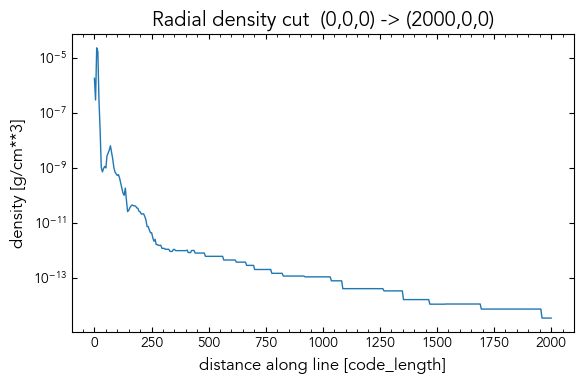

In [3]:
# --- Simplest case: a radial cut outward from the origin ---
# res[1] is distance along the line, res[2] is the field value there.
res = snap.line_profile("density", [0, 0, 0], [2000, 0, 0], res=400)
coords, dist, dens = res

plt.figure(figsize=(6, 4))
plt.plot(dist, dens)
plt.yscale("log")
plt.xlabel(f"distance along line [{dist.units}]")
plt.ylabel(f"density [{dens.units}]")
plt.title("Radial density cut  (0,0,0) -> (2000,0,0)")
plt.tight_layout()
plt.show()


Densest cell at (12, -2, -0) with density 2.007e-05 code_mass/code_length**3


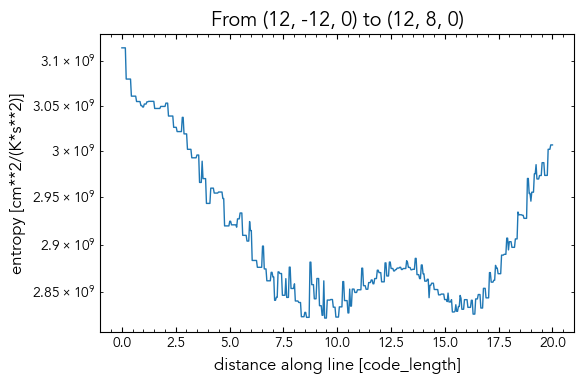

In [12]:
# --- A line through the densest cell (the forming disk) ---
# Centre the cut on the densest cell and run it horizontally across the disk.
ic = int(np.nanargmax(np.asarray(snap["density"])))
cx = float(np.asarray(snap["X"])[ic])
cy = float(np.asarray(snap["Y"])[ic])
cz = float(np.asarray(snap["Z"])[ic])
half = 10  # code length on either side of the centre

print(f"Densest cell at ({cx:.0f}, {cy:.0f}, {cz:.0f}) with density {snap['density'][ic]:.3e}")

p0 = [cx, cy - half, 0]
p1 = [cx, cy + half, 0]

coords, dist, prof = snap.line_profile("entropy", p0, p1, res=500)

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(dist, prof, color="C0", label="entropy")
ax1.set_yscale("log")
ax1.set_xlabel(f"distance along line [{dist.units}]")
ax1.set_ylabel(f"entropy [{prof.units}]")

plt.title(f"From ({p0[0]:.0f}, {p0[1]:.0f}, {p0[2]:.0f}) to ({p1[0]:.0f}, {p1[1]:.0f}, {p1[2]:.0f})")
plt.tight_layout()
plt.show()
